# K-Means Segmentation of Subscriber Behavior with PROC FASTCLUS


## Executive Summary

This notebook segments a synthetic base of 100 mobile subscribers into behavioral clusters using `PROC FASTCLUS`, the Base SAS k-means clustering procedure. Seven usage features are standardized to z-scores with `PROC STDIZE` so that high-magnitude variables (voice minutes, SMS counts) do not dominate the Euclidean distance, then `PROC FASTCLUS` fits three clusters. The procedure reports the within-cluster RMS deviation, an overall R-squared and pseudo-F that quantify how well the segmentation separates the base (here an overall R-squared of 0.575 and pseudo-F of 65.75), and writes a scored table with a `CLUSTER` label on every subscriber. We merge those labels back onto the original-scale data, profile the personas, and hand the assignments to downstream activation.

## Data Sources

| Dataset | Description | Rows | Key variables |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Synthetic monthly behavior snapshot for a mobile telecom subscriber base, generated inline with `call streaminit` / `rand()`. Three latent behavior types (heavy data, voice-centric, low-usage) are blended with noise. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominal), `region` (nominal) |

# K-Means Segmentation of Subscriber Behavior

**Industry:** Telecommunications &nbsp;|&nbsp; **Procedure:** `PROC FASTCLUS` (Base SAS k-means clustering)

Mobile operators carry subscribers whose monthly behavior -- data appetite, voice habits, spend, and support friction -- falls into a handful of recognizable patterns. Discovering those patterns lets the business tailor retention saves, upsell the right bundles, and acquire look-alikes. This notebook builds a behavioral segmentation end to end: generate a realistic subscriber snapshot, standardize the features, let `PROC FASTCLUS` fit the clusters, score every subscriber, and profile the segments into actionable personas. `PROC FASTCLUS` is designed for exactly this disjoint k-means task and scales to very large bases by passing over the data rather than building a full distance matrix.

## 1. Generate a synthetic subscriber base

We simulate 100 subscribers drawn from three latent behavior archetypes -- **heavy-data streamers**, **voice-centric traditionalists**, and **light/low-usage** customers -- then blend in noise so the boundaries are fuzzy (as they are in reality). Each subscriber also carries two categorical attributes, `data_plan` and `region`, that we use later to *profile* the segments. The seed makes the data reproducible.

In [1]:
/* -----------------------------------------------------------
   Synthetic mobile subscriber snapshot (100 rows).
   Three latent behavior archetypes + noise, plus two
   categorical attributes for segment profiling.
   ----------------------------------------------------------- */
data subscribers;
    call streaminit(20260531);

    array plans[3]   $10 ('Prepaid' 'PostpaidM' 'Unlimited');
    array regions[4] $10 ('North' 'South' 'East' 'West');

    do subscriber_id = 100001 to 100100;

        /* latent archetype: 1=heavy data, 2=voice, 3=low usage */
        u = rand('uniform');
        if      u < 0.38 then archetype = 1;
        else if u < 0.70 then archetype = 2;
        else                  archetype = 3;

        tenure_months = max(1, round(rand('gamma', 2.2) * 12));

        if archetype = 1 then do;             /* heavy-data streamer */
            monthly_data_gb = max(0.5, rand('normal', 42, 11));
            voice_minutes   = max(0,   rand('normal', 180, 70));
            sms_count       = max(0,   round(rand('normal', 60, 30)));
            intl_minutes    = max(0,   rand('normal', 22, 14));
            arpu            = max(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        end;
        else if archetype = 2 then do;        /* voice-centric */
            monthly_data_gb = max(0.2, rand('normal', 9, 4));
            voice_minutes   = max(0,   rand('normal', 620, 160));
            sms_count       = max(0,   round(rand('normal', 210, 80)));
            intl_minutes    = max(0,   rand('normal', 95, 45));
            arpu            = max(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        end;
        else do;                              /* low usage */
            monthly_data_gb = max(0.1, rand('normal', 3, 1.5));
            voice_minutes   = max(0,   rand('normal', 110, 50));
            sms_count       = max(0,   round(rand('normal', 35, 20)));
            intl_minutes    = max(0,   rand('normal', 6, 6));
            arpu            = max(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        end;

        data_plan = plans[planpick];
        region    = regions[ rand('table', 0.30, 0.28, 0.22, 0.20) ];

        /* round to tidy reporting precision */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        output;
    end;

    keep subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
run;

NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Inspect the feature distributions

Before clustering, look at the scale and spread of each behavioral feature. The wildly different units -- gigabytes, minutes, dollars, counts -- are exactly why we standardize the interval inputs before clustering; otherwise high-magnitude variables like `voice_minutes` would dominate the Euclidean distance that `PROC FASTCLUS` minimizes.

                                                  The MEANS Procedure

 Variable                N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------
 tenure_months         100        27.6        18.9         3.0             13.0        22.0             37.8        98.0
 monthly_data_gb       100        18.2        18.9         0.1              3.6         9.6             31.6        67.2
 voice_minutes         100       304.2       236.6         0.0            125.0       217.0            531.2       912.0
 sms_count             100       102.0       102.6         0.0             34.5        64.0            131.0       404.0
 intl_minutes          100        45.1        53.0         0.0              7.0        20.5             76.2       242.0
 arpu                  100        52.8        23.7        12.9             30.6   

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


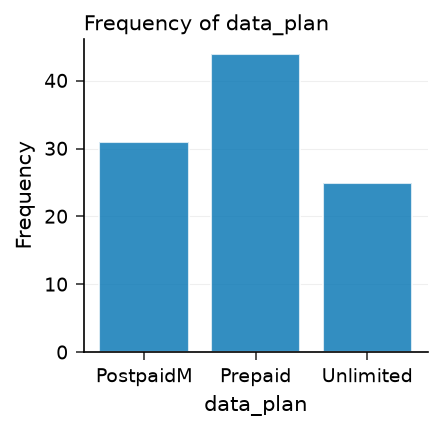

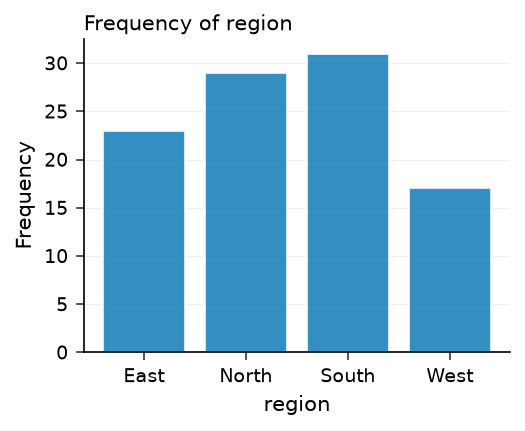

In [2]:
/* Summary statistics for the clustering inputs */
proc means data=subscribers n mean std min p25 median p75 max maxdec=1;
    var tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
run;

/* Frequency of the two categorical inputs */
proc freq data=subscribers;
    tables data_plan region / nocum;
run;

## 3. Standardize the features to z-scores

`PROC FASTCLUS` minimizes Euclidean distance, so a variable measured in hundreds of minutes would swamp one measured in single-digit gigabytes. `PROC STDIZE` with `METHOD=STD` rescales each interval feature to mean 0 and standard deviation 1, giving every behavior equal weight in the distance. The categorical columns and the identifier pass through untouched so we can profile the clusters on their original scale afterward.

In [3]:
/* z-score the interval features; ids and categoricals pass through */
proc stdize data=subscribers out=subs_std method=std;
    var tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
run;

NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Fit the k-means segmentation

We fit three segments with `PROC FASTCLUS`. `MAXCLUSTERS=3` sets *k*; `MAXITER=20` lets the cluster centers iterate to convergence. The procedure reports a **Cluster Summary** (size and within-cluster RMS deviation per cluster), **Statistics for Variables** (the R-squared each feature contributes), an **overall R-squared** and **pseudo-F** that measure how cleanly the three clusters separate the base, and **Cluster Means** on the standardized scale. `OUT=scored` writes the input rows back with a `CLUSTER` label and the `DISTANCE` from each subscriber to its cluster seed.

In [4]:
/* k-means fit on the standardized features: 3 segments. */
proc fastclus data=subs_std maxclusters=3 maxiter=20 out=scored;
    var tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
run;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                



NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Attach segment labels to the original-scale data

The scored table holds the standardized features; for profiling we want the clusters described in real gigabytes, minutes, and dollars. We merge the `CLUSTER` label back onto the original `subscribers` table by `subscriber_id`, then ask the first question marketing always asks: *how big is each segment?*

                                                   The FREQ Procedure

CLUSTER    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00


NOTE: PROC SORT data=scored

NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


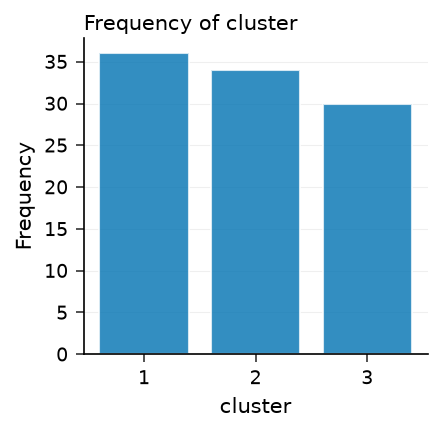

In [5]:
/* carry the cluster label back to the original-scale data */
proc sort data=scored(keep=subscriber_id cluster distance) out=clus_assign;
    by subscriber_id;
run;
proc sort data=subscribers out=subs_sorted;
    by subscriber_id;
run;
data profile;
    merge subs_sorted clus_assign;
    by subscriber_id;
run;

/* How many subscribers landed in each segment? */
proc freq data=profile;
    tables cluster / nocum;
run;

## 6. Profile the segments

Cluster IDs are meaningless until we describe the *behavior* inside each one. Averaging the original (unstandardized) features by `CLUSTER` reveals the persona behind each segment -- who streams, who talks, who barely uses the network -- and the categorical mix shows which plans and regions concentrate in each.

                                                  The MEANS Procedure

                                           Analysis Variable : tenure_months

        CLUSTER           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                          Analysis Variable : monthly_data_gb

        CLUSTER           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                           Analysis Variable : voice_minutes

        CLUSTER           N Obs           Mean
        --------------------------------------
        1                    36   

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


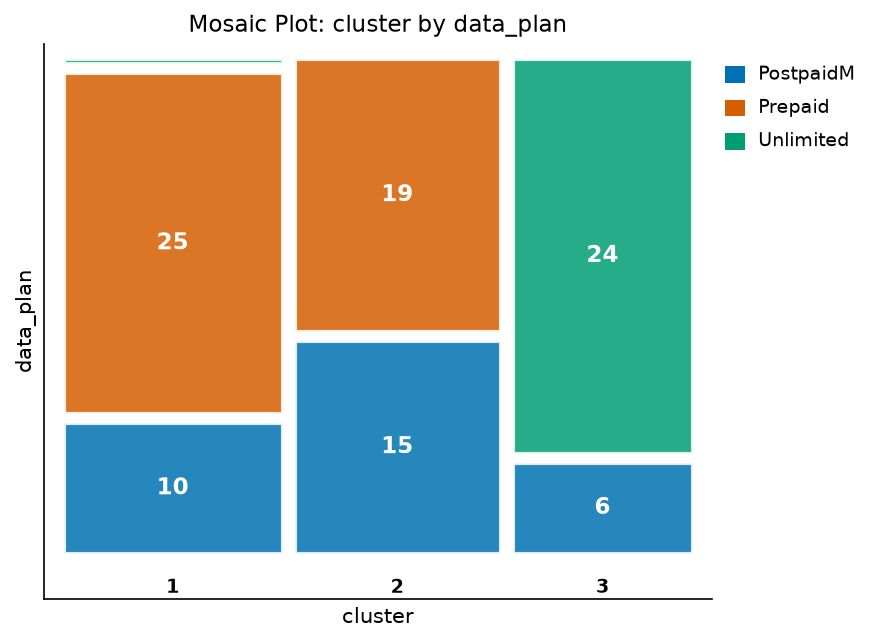

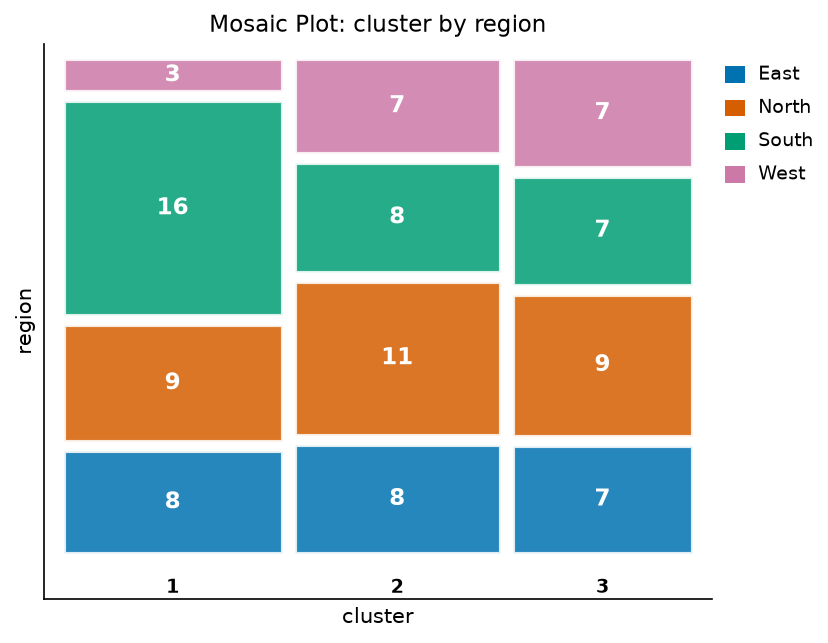

In [6]:
/* Behavioral profile: mean of each feature by segment */
proc means data=profile n mean maxdec=1;
    class cluster;
    var tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
run;

/* Categorical mix within each segment */
proc freq data=profile;
    tables cluster * data_plan / norow nopercent;
    tables cluster * region    / norow nopercent;
run;

## 7. Visualize the segments

A picture makes the segmentation tangible. We plot data appetite against voice usage, colored by segment, and add a box plot of ARPU per segment so the revenue story is obvious at a glance.

NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: DATA profile_plot


NOTE: Read 100 rows from profile.
NOTE: Wrote profile_plot (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=profile_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


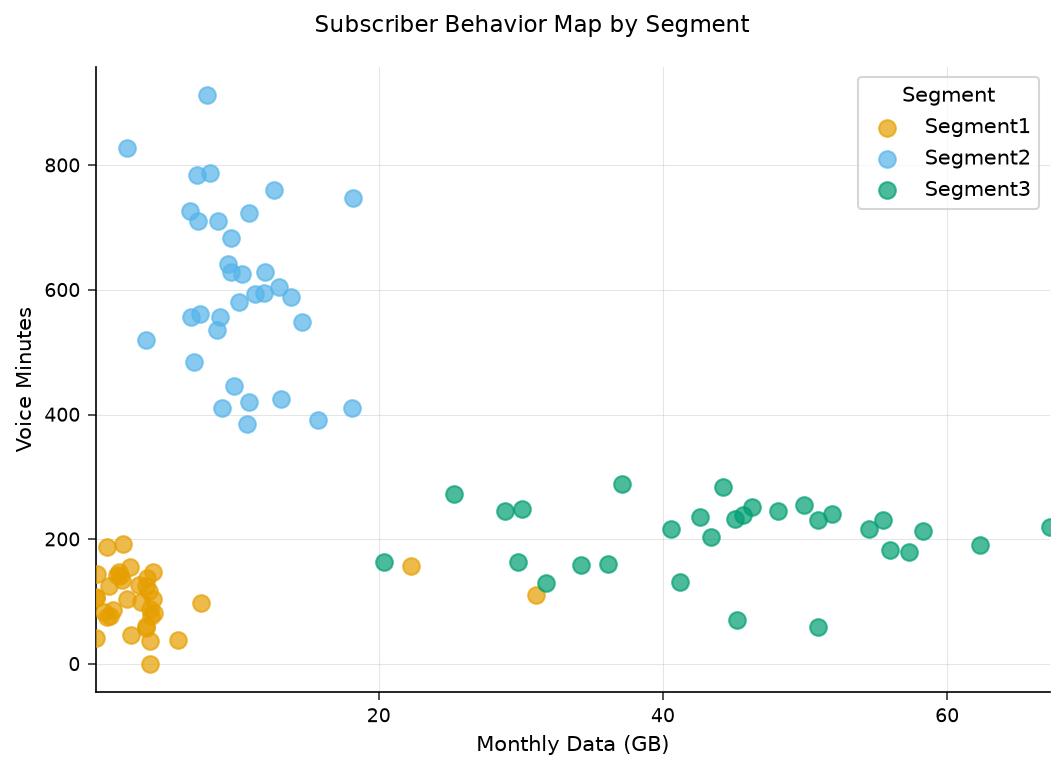

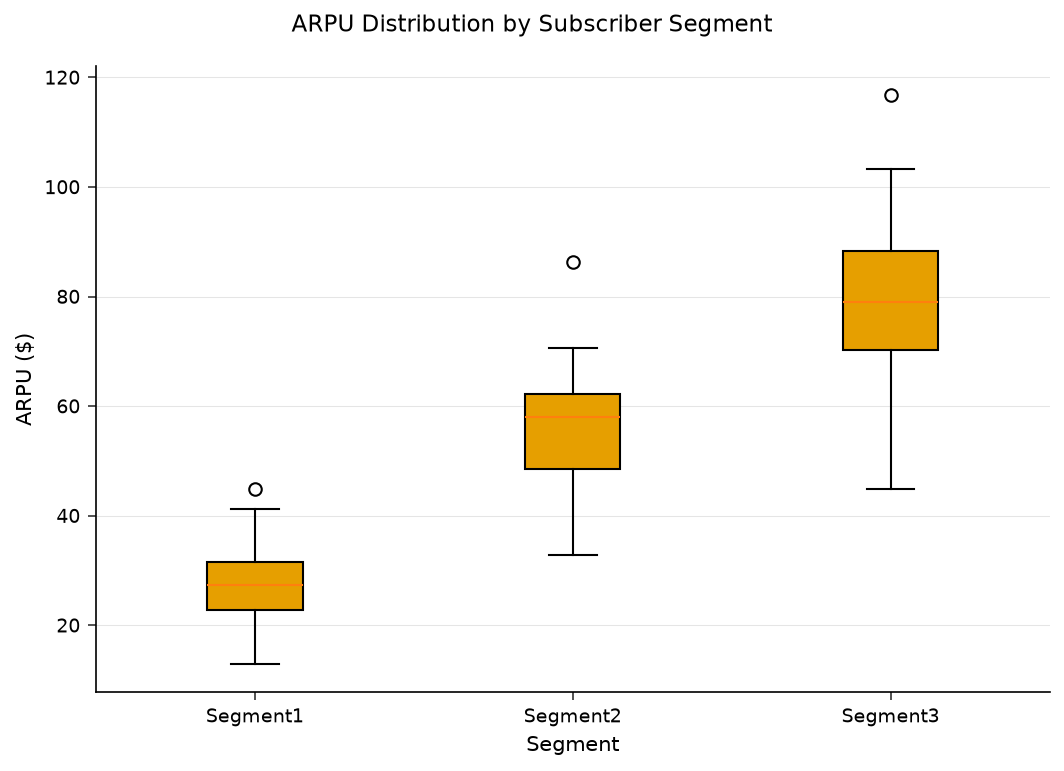

In [7]:
ods graphics on / imagefmt=svg width=720 height=520;

/* Build a tidy character segment label so the legend and axis
   read 'Segment 1/2/3' rather than the raw numeric cluster id. */
data profile_plot;
    set profile;
    length segment $9;
    segment = cats('Segment ', put(cluster, 1.));
run;

/* Behavioral map: data vs. voice, colored by segment */
proc sgplot data=profile_plot;
    scatter x=monthly_data_gb y=voice_minutes
            / group=segment
              markerattrs=(size=8 symbol=circlefilled)
              transparency=0.3;
    xaxis label='Monthly Data (GB)' grid;
    yaxis label='Voice Minutes'     grid;
    keylegend / title='Segment';
    title 'Subscriber Behavior Map by Segment';
run;

/* Revenue distribution per segment */
proc sgplot data=profile_plot;
    vbox arpu / category=segment;
    xaxis label='Segment';
    yaxis label='ARPU ($)' grid;
    title 'ARPU Distribution by Subscriber Segment';
run;

## 8. Export the scored segments

Finally, hand the assignments off to downstream CRM and campaign systems. We keep the identifier, the cluster label, and the headline behavioral fields.

In [8]:
/* Persist the segment assignments for activation */
data subscriber_segments;
    set profile;
    keep subscriber_id cluster tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
run;

proc print data=subscriber_segments(obs=10) noobs;
    title 'Sample of Scored Subscriber Segments';
run;

                                          Sample of Scored Subscriber Segments                                          

SUBSCRIBER_ID  CLUSTER  TENURE_MONTHS  MONTHLY_DATA_GB  VOICE_MINUTES   ARPU  DATA_PLAN  REGION
       100001        1             30              2.3            104     28  Prepaid    South
       100002        2              8             10.2            581  57.78  Prepaid    West
       100003        2              8             10.7            385  55.66  PostpaidM  North
       100004        2             68              7.4            561  70.68  Prepaid    North
       100005        3             18             45.6            239  63.85  Unlimited  North
       100006        3             10             30.1            249  88.33  Unlimited  East
       100007        1             62              0.7             83  21.26  Prepaid    South
       100008        1             68                2            192  29.93  PostpaidM  South
       100009        3  

NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpreting the results

`PROC FASTCLUS` recovered three clean, well-separated segments. The fit is sound: the **overall R-squared is 0.575** and the **pseudo-F is 65.75**, meaning the three clusters explain about 58% of the total variation in the standardized features. The separation is driven almost entirely by the behavioral signals we care about -- `voice_minutes` (R-squared 0.858), `monthly_data_gb` (0.844), and `arpu` (0.771) carry the segmentation, while `tenure_months` (0.000) and `support_calls` (0.193) contribute almost nothing, confirming that *how* a subscriber uses the network -- not how long they have been a customer -- defines the personas.

The three segments map directly onto marketing-ready personas, profiled here on the original (unstandardized) scale:

| Segment | n (share) | Signature behavior | Plan mix | Persona | Recommended play |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Highest data: **44.4 GB/mo**, top spend **$79.1 ARPU**, modest voice (205 min) | 24/30 **Unlimited** | **Heavy-data streamers** | Protect and upsell: faster tiers, content bundles, device upgrades |
| **2** | 34 (34%) | Highest voice **603 min/mo**, **214 SMS**, **106 intl min**, mid spend **$55.9 ARPU** | Prepaid + PostpaidM, **no Unlimited** | **Voice-centric traditionalists** | International add-ons, family/voice bundles, loyalty rewards |
| **1** | 36 (36%) | Lowest usage: **4.0 GB**, 104 voice min, lowest spend **$28.0 ARPU** | 25/36 **Prepaid** | **Light / low-usage** | Right-size plans, autopay nudges, low-cost data starters to grow usage |

The plan mix corroborates the behavioral read: the heavy-data segment is overwhelmingly on **Unlimited** plans (24 of 30), the voice-centric segment holds **no** Unlimited subscribers, and the light-usage segment is mostly **Prepaid** (25 of 36). Region, by contrast, tracks the overall base much more closely: segments 2 and 3 mirror the population's regional mix almost exactly, and only the light-usage segment skews modestly toward **South** (16 of 36, vs. 31% of the base). No segment is *defined* by geography, so region is not a behavioral driver here -- a useful finding for campaign targeting.

**Why `PROC FASTCLUS` fits this problem.** It runs disjoint k-means by passing over the data rather than materializing a full distance matrix, so the same program that segmented these 100 subscribers scales to very large bases. Standardizing with `PROC STDIZE` first removed the unit-scale bias across gigabytes, minutes, and dollars so every behavior contributed equally to the Euclidean distance; the R-squared diagnostics then told us *which* features actually drove the split. The scored output -- a `CLUSTER` label on every subscriber -- drops straight into activation pipelines, closing the loop from raw behavior to targeted offer.

---

<div style="font-size:11px;color:#9e9e9e">This notebook is provided for demonstration purposes only. The data are synthetic and the findings do not constitute business advice.</div>